# 合成控制法教程

### 加州 99 号提案与香烟消费

1988 年 11 月，加利福尼亚州通过 99 号提案（Proposition 99），从 1989 年起把每包香烟的消费税提高 25 美分，并把税收用于控烟宣传。这项政策让加州的人均香烟消费下降了多少？

这是一个典型的**只有一个处理单位**的问题。没有处理组的「平均」可言，传统的回归和 DID 都不太适用。Abadie, Diamond and Hainmueller (2010) 用这个案例展示了合成控制法（synthetic control）。数据随 StatsPAI 自带，本教程全程离线。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | 问题与思路 | 为什么不直接做 DID |
| 2 | 数据 | 39 个州、31 年的面板 |
| 3 | 一个朴素的 DID | 拿其他州的平均当对照会怎样 |
| 4 | 合成控制 | 权重怎么选，结果怎么读 |
| 5 | 拟合质量 | 处理前拟合得好不好决定了结果能不能信 |
| 6 | 推断 | 安慰剂检验，RMSPE 比值，p 值和置信区间从哪来 |
| 7 | 稳健性 | 时间安慰剂，留一法 |
| 8 | 其他合成控制估计量 | 去均值、增广、合成 DID |
| 9 | 小结 | 一份清单 |

## 1. 问题与思路

要估计 99 号提案的效应，需要知道**如果没有这项政策**，加州 1989 年之后的香烟消费会是多少。这个反事实观测不到，只能用其他州来构造。

最直接的想法是做 DID，拿其他州的平均当对照。它依赖平行趋势假设，没有政策时加州的消费变化应该和其他州的平均变化一样。可是加州和「其他州的平均」在政策之前的走势就不一样，这个假设很难让人信服。

合成控制法换了一个思路。**不要求所有对照州等权重，而是找一组权重，让对照州的加权组合在政策之前尽可能贴近加州**。这个加权组合叫「合成加州」。如果它在政策前十几年里一直紧跟真实的加州，我们就有理由相信它在政策之后也能代表加州本来的走势。

形式化地写，设加州是第 1 个单位，其余 $J$ 个州是备选的对照（donor pool）。合成控制的权重 $w = (w_2, \dots, w_{J+1})$ 满足

$$
w_j \ge 0, \qquad \sum_{j=2}^{J+1} w_j = 1,
$$

并且使处理前的特征差距最小。处理后第 $t$ 期的效应估计是

$$
\hat\tau_{t} = Y_{1t} - \sum_{j=2}^{J+1} \hat w_j\, Y_{jt}.
$$

权重非负且和为 1，意味着合成加州是对照州的**凸组合**，不做外推。这个约束是合成控制可解释性的来源，每个对照州贡献了多少一目了然。

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp

plt.rcParams["figure.dpi"] = 80
pd.set_option("display.width", 120)
print("StatsPAI 版本:", sp.__version__)

StatsPAI 版本: 1.39.2


## 2. 数据

`sp.datasets.california_prop99()` 是 39 个州、1970 到 2000 年的平衡面板。其余 11 个州和华盛顿特区在样本期内也推行了大规模控烟项目或大幅提高了烟草税，不适合当对照，原始研究把它们排除了。

| 变量 | 含义 |
| --- | --- |
| `state`, `year` | 州，年份 |
| `cigsale` | 人均香烟销量（包） |
| `retprice` | 香烟零售价格 |
| `lnincome`, `beer`, `age15to24` | 人均收入对数、人均啤酒消费、15 到 24 岁人口比例（部分年份缺失） |
| `treated` | 加州 1989 年及以后为 1 |

In [2]:
prop99 = sp.datasets.california_prop99()
prop99["year"] = prop99["year"].astype(int)

print(prop99.shape, "|", prop99["state"].nunique(), "个州 |", prop99["year"].min(), "到", prop99["year"].max())
prop99.head()

(1209, 8) | 39 个州 | 1970 到 2000


,state,year,cigsale,lnincome,beer,age15to24,retprice,treated
0,Rhode Island,1970,123.900002,NaN,NaN,0.183158,39.299999,0
1,Tennessee,1970,99.800003,NaN,NaN,0.178044,39.900002,0
2,Indiana,1970,134.600006,NaN,NaN,0.176516,30.600000,0
3,Nevada,1970,189.500000,NaN,NaN,0.161554,38.900002,0
4,Louisiana,1970,115.900002,NaN,NaN,0.185185,34.299999,0


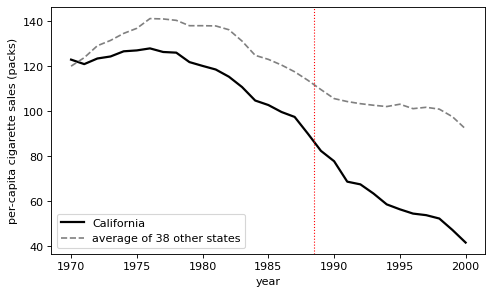

In [3]:
# 加州与其余 38 个州的简单平均
ca = prop99[prop99["state"] == "California"].set_index("year")["cigsale"]
others = prop99[prop99["state"] != "California"].groupby("year")["cigsale"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ca, color="black", lw=2, label="California")
ax.plot(others, color="grey", ls="--", label="average of 38 other states")
ax.axvline(1988.5, color="red", ls=":", lw=1)
ax.set_xlabel("year")
ax.set_ylabel("per-capita cigarette sales (packs)")
ax.legend()
plt.show()

政策之前，加州的香烟消费就低于其他州的平均，而且从 70 年代末开始下降得更快。两条线并不平行。

## 3. 一个朴素的 DID

先算一下拿其他州的简单平均当对照会得到什么。

In [4]:
pre, post = slice(1970, 1988), slice(1989, 2000)

did_naive = (ca.loc[post].mean() - ca.loc[pre].mean()) - (others.loc[post].mean() - others.loc[pre].mean())
print(f"加州的变化     : {ca.loc[post].mean() - ca.loc[pre].mean():7.1f} 包")
print(f"其他州的变化   : {others.loc[post].mean() - others.loc[pre].mean():7.1f} 包")
print(f"朴素 DID 估计  : {did_naive:7.1f} 包")

加州的变化     :   -55.9 包
其他州的变化   :   -28.5 包
朴素 DID 估计  :   -27.3 包


朴素 DID 说政策使人均消费减少了约 27 包。问题在于，加州在政策前的下降趋势本来就比其他州陡，这部分差异被全部算进了政策效应。这个数字很可能高估了政策的作用。

## 4. 合成控制

`sp.synth` 是 StatsPAI 里所有合成控制方法的统一入口，默认的 `method="classic"` 就是经典的合成控制。需要告诉它结果变量、单位、时间、处理单位和处理开始的时点。

这里用处理前每一年的香烟销量作为匹配特征。也就是说，权重的选取目标是让合成加州在 1970 到 1988 年的销量轨迹尽量贴近真实的加州。

In [5]:
kw = dict(outcome="cigsale", unit="state", time="year", treated_unit="California", treatment_time=1989)

sc = sp.synth(prop99, **kw)

print(f"平均处理效应（1989 到 2000 年的平均差距）: {sc.estimate:.2f} 包")
print(f"处理前拟合误差 RMSPE                  : {sc.model_info['pre_treatment_rmse']:.2f} 包")
print("\n合成加州的构成:")
print(sc.detail.round(3).to_string(index=False))

平均处理效应（1989 到 2000 年的平均差距）: -19.51 包
处理前拟合误差 RMSPE                  : 1.66 包

合成加州的构成:
         unit  weight
         Utah   0.394
      Montana   0.232
       Nevada   0.205
  Connecticut   0.109
New Hampshire   0.045
     Colorado   0.015


38 个备选州里只有 6 个得到了正的权重，犹他、蒙大拿和内华达三个州占了八成以上。权重稀疏是合成控制的典型特征，它来自非负和求和为 1 的约束。稀疏的好处是结果可以被检视。读者可以问，用这几个州来代表加州合理吗？

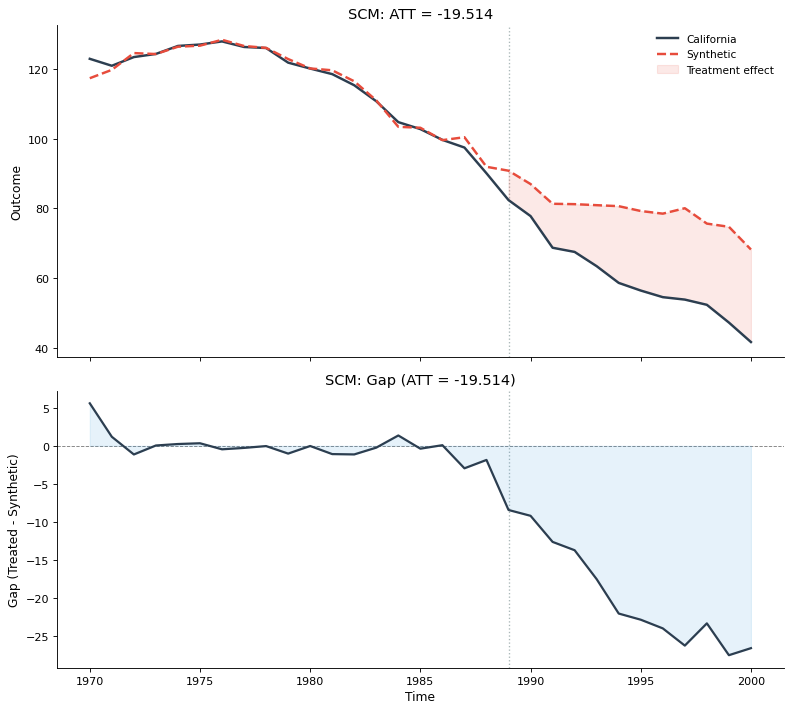

In [6]:
fig, axes = sc.plot()
plt.show()

上图是真实加州与合成加州的销量轨迹，下图是两者之差。

- 1989 年之前两条线几乎重合。处理前的拟合误差只有 1.7 包，而销量本身在 100 包以上。
- 1989 年之后两条线分开，差距逐年扩大。

逐年的差距存在 `model_info["gap_table"]` 里。

In [7]:
gap = sc.model_info["gap_table"]
gap[gap["post_treatment"]].round(1)

,time,treated,synthetic,gap,post_treatment
19,1989,82.4,90.8,-8.4,True
20,1990,77.8,87.0,-9.2,True
21,1991,68.7,81.3,-12.6,True
22,1992,67.5,81.2,-13.7,True
23,1993,63.4,80.9,-17.5,True
24,1994,58.6,80.6,-22.0,True
25,1995,56.4,79.3,-22.9,True
26,1996,54.5,78.5,-24.0,True
27,1997,53.8,80.1,-26.3,True
28,1998,52.3,75.6,-23.3,True


到 2000 年，加州的人均香烟销量比合成加州低约 27 包。12 年的平均差距是 19.5 包，比朴素 DID 的 27 包小了不少。差别来自对照组的选法。合成加州复制了真实加州在政策前的下降趋势，朴素 DID 没有。

## 5. 拟合质量

合成控制的可信度建立在一个前提上。合成单位在处理前**足够长**的时间里**足够好**地跟踪了处理单位。如果处理前都拟合不好，处理后的差距就不能解读为政策效应。

`model_info["predictor_balance"]` 把每个匹配特征在加州、合成加州和全部对照州简单平均上的取值并排列出。

In [8]:
balance = sc.model_info["predictor_balance"].copy()
balance["gap_synth"] = balance["synthetic"] - balance["treated"]
balance["gap_donor_mean"] = balance["donor_mean"] - balance["treated"]
balance.iloc[::3].round(1)   # 每隔三年显示一行

,predictor,treated,synthetic,donor_mean,gap_synth,gap_donor_mean
0,cigsale[1970],123.0,117.4,120.1,-5.6,-2.9
3,cigsale[1973],124.4,124.4,131.5,-0.0,7.1
6,cigsale[1976],128.0,128.5,141.3,0.5,13.3
9,cigsale[1979],121.9,122.9,138.1,1.0,16.2
12,cigsale[1982],115.4,116.5,136.3,1.1,20.9
15,cigsale[1985],102.8,103.2,123.1,0.4,20.3
18,cigsale[1988],90.1,92.0,113.8,1.9,23.7


除了样本的第一年，合成加州与真实加州的差距都在 2 包以内。对照州的简单平均则从 70 年代中期开始系统性地高于加州，到 1988 年高出二十多包。这就是第 3 节朴素 DID 的问题所在。

还可以看两个汇总指标。

In [9]:
mi = sc.model_info
print(f"得到正权重的对照州个数 : {mi['n_active_donors']}")
print(f"有效对照州个数          : {mi['effective_n_donors']}   (权重平方和的倒数)")
print(f"处理前 R²               : {mi['pre_r2']:.4f}")

得到正权重的对照州个数 : 6
有效对照州个数          : 3.77   (权重平方和的倒数)
处理前 R²               : 0.9788


## 6. 推断

只有一个处理单位，常规的标准误和 t 检验没有意义。Abadie, Diamond and Hainmueller (2010) 建议用**安慰剂检验**（也叫空间安慰剂或置换检验）。

做法是轮流把每一个对照州假装成处理单位，用同样的方法为它构造合成控制，算出「安慰剂效应」。这些州实际上没有受到政策影响，它们的安慰剂效应反映的是方法本身的噪声有多大。如果加州的效应在这个分布里显得异常，就有理由认为它不是偶然。

`sp.synth` 默认已经做了这一步（`placebo=True`），结果存在 `model_info` 里。

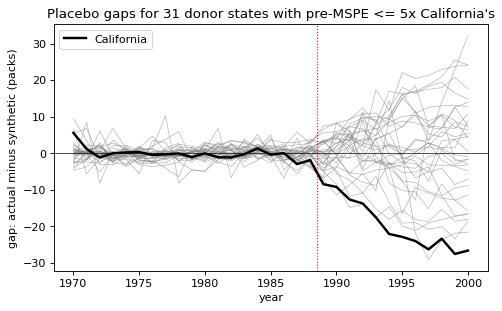

In [10]:
times = np.asarray(mi["times"]).astype(int)
placebo_gaps = np.asarray(mi["placebo_gaps"])        # 形状为 (年份数, 对照州数)
ptable = mi["placebo_table"]

# 处理前拟合太差的安慰剂州没有参考价值。这里只画处理前 MSPE 不超过加州 5 倍的州
keep = ptable.loc[mi["placebo_units"], "pre_mspe_relative"].values <= 5

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(times, placebo_gaps[:, keep], color="grey", lw=0.6, alpha=0.6)
ax.plot(times, gap["gap"], color="black", lw=2.2, label="California")
ax.axvline(1988.5, color="red", ls=":", lw=1)
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("year")
ax.set_ylabel("gap: actual minus synthetic (packs)")
ax.set_title(f"Placebo gaps for {keep.sum()} donor states with pre-MSPE <= 5x California's")
ax.legend()
plt.show()

灰线是各个对照州的安慰剂差距，黑线是加州。1989 年之后，加州的线逐渐落到灰线束的下缘。

### RMSPE 比值

肉眼比较有一个问题。有些州在处理前就拟合得不好，处理后差距大并不稀奇。更规范的统计量是**处理后与处理前的 MSPE 之比**。

$$
r_j = \frac{\text{处理后的均方预测误差}}{\text{处理前的均方预测误差}}.
$$

处理前拟合得好、处理后差距却很大的单位，这个比值才会高。p 值就是加州的比值在所有 39 个州里的排名除以 39。

In [11]:
ranked = ptable.sort_values("ratio", ascending=False)
print(ranked.head(6).round(2).to_string())

rank_ca = int((ptable["ratio"] >= ptable.loc["California", "ratio"]).sum())
print(f"\n加州的比值排第 {rank_ca} 位，共 {len(ptable)} 个州。p = {rank_ca}/{len(ptable)} = {rank_ca / len(ptable):.3f}")
print(f"sp.synth 报告的 p 值: {sc.pvalue:.3f}")

            pre_mspe  post_mspe   ratio  pre_mspe_relative
unit                                                      
Missouri        0.19     109.70  572.38               0.07
Virginia        0.67     261.64  393.13               0.24
California      2.74     424.59  154.75               1.00
Nebraska        0.71      72.44  101.84               0.26
Georgia         1.19      97.93   82.11               0.43
Texas           3.68     245.87   66.89               1.34

加州的比值排第 3 位，共 39 个州。p = 3/39 = 0.077
sp.synth 报告的 p 值: 0.077


加州排第 3，p = 0.077。这个结果值得仔细读。

- 密苏里和弗吉尼亚的比值比加州还高。原因是它们处理前拟合得**极好**（MSPE 分别只有 0.19 和 0.67），分母很小。它们处理后的 MSPE 其实都低于加州的 425。
- 置换检验的 p 值有下限。39 个州时最小的可能 p 值是 1/39 ≈ 0.026。对照州越少，这类检验的分辨率越低。
- 原始论文报告加州的比值排第一。那里的匹配特征除了几个年份的销量，还包括零售价格、收入等协变量，设定与本教程不同。**匹配特征的选择会影响结果**，这是合成控制里一个实实在在的研究者自由度，应该事先定好并如实汇报。

### 逐年的检验和置信区间

`placebo_effects` 给出每个处理后年份的安慰剂 p 值。`p_left` 是「加州的差距比它更负的州所占比例」，对应单侧的备择假设「政策降低了消费」。

In [12]:
mi["placebo_effects"].round(3)

,time,effect,p_two_sided,p_right,p_left
0,1989,-8.440,0.154,0.949,0.077
1,1990,-9.207,0.231,0.846,0.179
2,1991,-12.634,0.154,0.897,0.128
3,1992,-13.729,0.128,0.923,0.103
4,1993,-17.534,0.103,0.949,0.077
5,1994,-22.049,0.077,0.974,0.051
6,1995,-22.858,0.077,0.974,0.051
7,1996,-23.997,0.077,0.974,0.051
8,1997,-26.261,0.103,0.949,0.077
9,1998,-23.338,0.103,0.949,0.077


1990 到 1992 年，加州的差距在安慰剂分布里并不突出，单侧 p 值在 0.1 以上。1993 年之后单侧 p 值稳定在 0.08 以下，2000 年时加州的差距是 39 个州里最负的。效应是逐渐累积起来的。

`sp.synth` 报告的置信区间来自对同一个置换检验的反演，所以它和 p 值是一致的。

In [13]:
print(f"ATT = {sc.estimate:.1f},  95% 置信区间 = [{sc.ci[0]:.1f}, {sc.ci[1]:.1f}],  p = {sc.pvalue:.3f}")

ATT = -19.5,  95% 置信区间 = [-58.6, 19.6],  p = 0.077


区间很宽，并且包含 0，与 p = 0.077 在 5% 水平上不显著是同一件事。一个处理单位加 38 个对照单位，能提供的统计证据本来就有限。合成控制的说服力更多来自拟合图、安慰剂图和下面的稳健性检验合在一起讲的故事，而不是某一个 p 值。

## 7. 稳健性

### 时间安慰剂

把政策时点假装提前到 1980 年，只用 1989 年之前的数据重做一遍。1980 到 1988 年并没有政策，如果这段时间也出现了很大的「效应」，就说明合成控制在这份数据上不可靠。

假想政策时点 1980 年。1980 到 1988 年的平均差距: -3.37 包,  p = 0.385


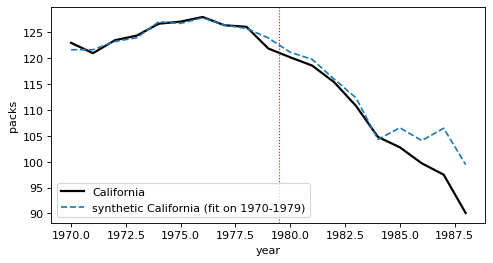

In [14]:
pre_data = prop99[prop99["year"] < 1989]
backdated = sp.synth(pre_data, **{**kw, "treatment_time": 1980})

print(f"假想政策时点 1980 年。1980 到 1988 年的平均差距: {backdated.estimate:.2f} 包,  p = {backdated.pvalue:.3f}")

bgap = backdated.model_info["gap_table"]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(bgap["time"], bgap["treated"], color="black", lw=2, label="California")
ax.plot(bgap["time"], bgap["synthetic"], color="C0", ls="--", label="synthetic California (fit on 1970-1979)")
ax.axvline(1979.5, color="red", ls=":", lw=1)
ax.set_xlabel("year")
ax.set_ylabel("packs")
ax.legend()
plt.show()

假想时点之后的平均差距约为 −3.4 包，安慰剂 p 值 0.38，远小于真实政策时点之后的 −19.5 包。

不过它也不是 0。只用 1970 到 1979 年拟合出来的合成加州，在 80 年代略微高估了加州的销量，说明加州在政策之前就有一点相对下降的趋势没有被完全捕捉。这提示真实效应可能比 19.5 包略小。如实写出这一点，比只说「时间安慰剂检验通过」更有信息量。

### 留一法

合成加州主要由三四个州构成。如果去掉其中某一个，结果会不会大变？`sp.synth_loo` 逐个去掉对照州重新估计。

In [15]:
loo = sp.synth_loo(prop99, **kw)

# 只看那些去掉之后结果有变化的州，也就是原来权重为正的州
changed = loo[(loo["att"] - sc.estimate).abs() > 1e-6]
print(changed[["dropped_unit", "att", "pre_rmse"]].round(2).to_string(index=False))
print(f"\n留一法下 ATT 的范围: [{loo['att'].min():.1f}, {loo['att'].max():.1f}]，基准估计 {sc.estimate:.1f}")

 dropped_unit    att  pre_rmse
       Nevada -19.17      2.22
New Hampshire -19.78      1.70
         Utah -19.14      2.38
     Colorado -19.60      1.66
      Montana -17.97      1.76
  Connecticut -20.51      1.81

留一法下 ATT 的范围: [-20.5, -18.0]，基准估计 -19.5


去掉任何一个州，估计值都在 −18 到 −20.5 之间。结果不依赖某一个特定的对照州。

## 8. 其他合成控制估计量

经典合成控制之后，文献发展出了许多变体。它们放松了经典方法的不同约束。

| `method` | 方法 | 与经典方法的区别 |
| --- | --- | --- |
| `"classic"` | Abadie, Diamond and Hainmueller (2010) | 基准 |
| `"demeaned"` | Ferman and Pinto (2021) | 先减去各单位处理前的均值，允许处理单位和合成单位之间有固定的水平差 |
| `"augmented"` | Ben-Michael, Feller and Rothstein (2021) | 用结果模型校正处理前拟合不完美带来的偏差，权重可以为负 |
| `"sdid"` | Arkhangelsky et al. (2021) | 合成 DID。同时给单位和时期加权，并允许水平差 |

`sp.synth_compare` 一次跑多个方法并把结果并排列出。合成 DID 的标准误来自安慰剂重抽样，带有随机性，`seed=` 用来固定它。这个单元格需要十几秒。

In [16]:
cmp = sp.synth_compare(prop99, methods=["classic", "demeaned", "augmented", "sdid"], seed=0, **kw)
cmp.comparison_table[["method", "att", "se", "pvalue", "ci_lower", "ci_upper", "pre_rmspe", "n_effective_donors"]].sort_values("att").round(2).reset_index(drop=True)

,method,att,se,pvalue,ci_lower,ci_upper,pre_rmspe,n_effective_donors
0,classic,-19.51,10.80,0.08,-58.59,19.56,1.66,6.0
1,augmented,-15.95,9.90,0.10,-35.36,3.46,0.73,22.0
2,sdid,-15.60,10.28,0.13,-35.75,4.54,NaN,21.0
3,demeaned,-11.11,9.99,0.08,-30.69,8.48,0.96,9.0


四个方法的点估计在 −11 到 −19.5 包之间，方向一致，大小有差别。

`pre_rmspe` 是处理前的拟合误差，`n_effective_donors` 是权重超过 0.01 的对照州个数。合成 DID 的模型里带截距，不报告水平上的拟合误差，所以那一格为空。增广方法允许负权重，用到的对照州也更多。

- 允许水平差的方法（去均值和合成 DID）给出的效应更小。它们不要求合成加州在水平上与加州重合，只要求变化趋势相似，选出来的对照州组合不一样。
- 四个置信区间都包含 0。只有一个处理单位时，无论用哪种方法，推断的精度都有限。

如实的总结是，99 号提案很可能使加州的人均香烟消费在随后 12 年里平均每年减少十几到二十包，点估计对方法的选择有一定敏感性，统计上的不确定性不小。

## 9. 小结

做合成控制时可以对照这份清单。

1. **确认方法适用**。处理单位很少，处理前的时期足够长，对照单位没有受到政策的溢出影响。
2. **事先确定对照池和匹配特征**。排除受到类似政策影响的单位，记录理由。
3. **检查处理前拟合**（`sc.plot()`，`model_info["predictor_balance"]`）。拟合不好就不要往下解读。
4. **汇报权重**（`sc.detail`）。看看这些对照单位是否说得通。
5. **安慰剂推断**。汇报 RMSPE 比值的排名和 p 值，说明对照单位个数决定了 p 值的下限。
6. **时间安慰剂和留一法**（`sp.synth_loo`）。
7. **换方法复核**（`sp.synth_compare`）。

`sp.synth` 还支持二十多种其他方法，以及多个处理单位、交错处理等情形。详见 `docs/guides/synth.md`。

### 本教程用到的方法的文献

下面的 BibTeX 条目直接取自 StatsPAI 核验过的 `paper.bib`。

In [17]:
keys = [
    "abadie2010synthetic",
    "abadie2021synthetic",
    "firpo2018synthetic",
    "ferman2021synthetic",
    "benmichael2021augmented",
    "arkhangelsky2021synthetic",
]
print(sp.bibtex(keys))

@article{abadie2010synthetic,
  title={Synthetic Control Methods for Comparative Case Studies: Estimating the Effect of {California}'s Tobacco Control Program},
  author={Abadie, Alberto and Diamond, Alexis and Hainmueller, Jens},
  journal={Journal of the American Statistical Association},
  volume={105},
  number={490},
  pages={493--505},
  year={2010},
  publisher={Taylor \& Francis},
  doi={10.1198/jasa.2009.ap08746}
}

@article{abadie2021synthetic,
  title={Using Synthetic Controls: Feasibility, Data Requirements, and Methodological Aspects},
  author={Abadie, Alberto},
  journal={Journal of Economic Literature},
  volume={59},
  number={2},
  pages={391--425},
  year={2021},
  doi={10.1257/jel.20191450}
}

@article{firpo2018synthetic,
  title={Synthetic Control Method: Inference, Sensitivity Analysis and Confidence Sets},
  author={Firpo, Sergio and Possebom, Vitor},
  journal={Journal of Causal Inference},
  year={2018},
  doi={10.1515/jci-2016-0026}
}

@article{ferman2021synth